In [1]:
import pandas as pd 
import numpy as np 

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [9]:
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_moons.shape

(300, 2)

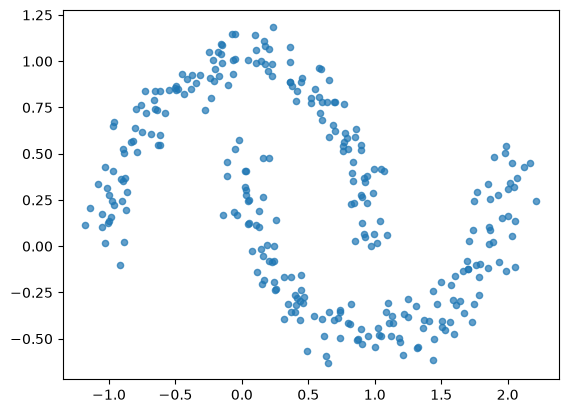

In [10]:
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20, alpha=0.7)

In [11]:
from sklearn.preprocessing import StandardScaler 
scaler=StandardScaler()
X_moons_scaled=scaler.fit_transform(X_moons)

In [12]:
dbscan=DBSCAN(eps=0.2,min_samples=7,n_jobs=-1)
pred=dbscan.fit_predict(X_moons_scaled)

In [13]:
pred

array([ 0,  0, -1,  1,  0,  0,  0,  1,  2,  0,  0,  1,  0,  1,  0,  0,  3,
        0, -1,  4,  1,  1,  0,  0,  1,  1, -1,  3,  4,  0,  1,  4,  1,  1,
        0,  1,  2,  1,  1,  1,  1,  1, -1,  1,  1,  1,  0,  0,  1,  0,  0,
        5,  0,  1,  3, -1,  1,  1,  0,  1,  0,  1,  2,  0,  0,  1,  1,  0,
        1,  0,  1,  5,  0,  0,  5,  3,  1,  1,  1,  3,  4, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  0, -1, -1,  1,  0,  1,
        1,  0,  0,  0,  5,  1,  0,  1,  5,  0,  1,  0,  0,  1,  5,  3,  0,
        0,  1,  4,  0,  0,  5,  0,  1,  5,  0, -1,  5,  1,  4,  1, -1,  0,
        4,  0,  0,  2,  1,  5,  0,  1, -1,  0,  1,  1,  1,  1,  0,  1,  0,
        4, -1,  0,  0,  1,  0,  1,  0,  4,  1,  1,  1,  5, -1,  0,  4,  1,
        1,  0,  0,  1, -1,  0,  5,  1, -1,  5,  0,  2, -1,  0,  1,  0,  0,
        4,  1,  1,  1, -1,  0, -1,  0,  1,  3,  0,  1,  0,  2,  1,  1,  0,
        4,  0,  3,  5,  1,  5,  1,  3,  2,  1,  0,  1,  1, -1,  4,  1,  1,
       -1,  0, -1,  1,  0

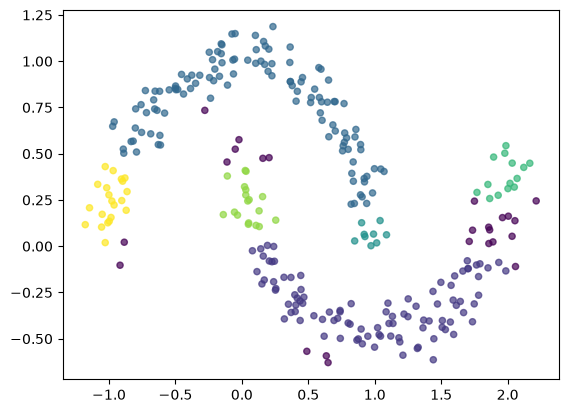

In [14]:
plt.scatter(X_moons[:, 0], X_moons[:, 1],c=pred, s=20, alpha=0.7)

In [15]:
X_s = StandardScaler().fit_transform(X_moons)

print(f"{'eps':<8} {'min_s':<8} {'Clusters':<12} {'Noise %'}")
print("-" * 42)

for eps in [0.1, 0.2, 0.3, 0.5, 1.0]:
    for min_s in [3, 5, 10]:
        db_test = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db_test.fit_predict(X_s)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct  = (lbl == -1).mean() * 100
        print(f"{eps:<8} {min_s:<8} {n_clusters:<12} {noise_pct:.1f}%")
    print()


eps      min_s    Clusters     Noise %
------------------------------------------
0.1      3        30           33.3%
0.1      5        15           67.3%
0.1      10       0            100.0%

0.2      3        8            1.3%
0.2      5        7            3.3%
0.2      10       7            36.7%

0.3      3        2            0.0%
0.3      5        2            0.0%
0.3      10       2            0.7%

0.5      3        1            0.0%
0.5      5        1            0.0%
0.5      10       1            0.0%

1.0      3        1            0.0%
1.0      5        1            0.0%
1.0      10       1            0.0%

